In [8]:
from torch.utils.data import DataLoader
from rdkit import Chem
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
from dgllife.utils import smiles_to_bigraph, CanonicalAtomFeaturizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd
import os
import random
import warnings
from joblib import dump, load

warnings.filterwarnings("ignore")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class DrugGeneInteractionTransformer(nn.Module):
    def __init__(self, atom_dim, gene_dim, dim, depth, heads, dropout):
        super().__init__()
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, 
            nhead=heads, 
            dim_feedforward=dim * 4, 
            dropout=dropout,
            activation='gelu', 
            batch_first=True
        )

        self.drug_embedding = nn.Linear(atom_dim, dim)
        self.drug_cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.drug_transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.gene_embedding = nn.Linear(gene_dim, dim)
        self.gene_cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.gene_transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.output_layer = nn.Sequential(
            nn.LayerNorm(dim * 2),
            nn.Linear(dim * 2, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, 1),
            nn.Sigmoid()
        )

    def forward(self, atom_features, gene_features, label=None):

        b, n_atoms, _ = atom_features.shape
        drug_x = self.drug_embedding(atom_features)
        drug_cls_tokens = self.drug_cls_token.repeat(b, 1, 1)
        drug_input = torch.cat((drug_cls_tokens, drug_x), dim=1)
        drug_encoded = self.drug_transformer(drug_input)
        drug_repr = drug_encoded[:, 0]

        gene_x = self.gene_embedding(gene_features.unsqueeze(1))
        gene_cls_tokens = self.gene_cls_token.repeat(b, 1, 1)
        gene_input = torch.cat((gene_cls_tokens, gene_x), dim=1)
        gene_encoded = self.gene_transformer(gene_input)
        gene_repr = gene_encoded[:, 0]
        
        fused_repr = torch.cat((drug_repr, gene_repr), dim=1)
        logit = self.output_layer(fused_repr)
        
        loss = None
        if label is not None:
            loss = F.binary_cross_entropy(logit.view(-1), label.float().view(-1))

        return logit, loss

    def get_atom_attention(self, atom_features):
        self.eval()
        with torch.no_grad():
            b, n_atoms, _ = atom_features.shape
            drug_x = self.drug_embedding(atom_features)
            drug_cls_tokens = self.drug_cls_token.repeat(b, 1, 1)
            drug_input = torch.cat((drug_cls_tokens, drug_x), dim=1)
            x = drug_input
            last_attn_weights = None
            
            for layer in self.drug_transformer.layers:
                attn_module = layer.self_attn
                _x, weights = attn_module(x, x, x, need_weights=True)
                x = layer(x) 
                last_attn_weights = weights 
            

            cls_attention = last_attn_weights[:, 0, 1:] # (batch, n_atoms)
            
            return cls_attention

class DrugGeneDataset(torch.utils.data.Dataset):
    def __init__(self, df, atom_featurizer, max_atoms=100):
        self.df = df
        self.atom_featurizer = atom_featurizer
        self.max_atoms = max_atoms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        smiles = row['smiles']
        gene_features = torch.tensor(row.iloc[2:-2].astype(float).values, dtype=torch.float32)
        
        try:
            mol = Chem.MolFromSmiles(smiles)
            atom_feats = self.atom_featurizer(mol)['h']
        except:
            # Fallback for invalid SMILES (should be cleaned beforehand)
            atom_feats = torch.zeros(1, 74) 

        n_atoms = atom_feats.shape[0]
        padded_atom_feats = torch.zeros(self.max_atoms, atom_feats.shape[1])
        if n_atoms > self.max_atoms:
            padded_atom_feats = atom_feats[:self.max_atoms, :]
        else:
            padded_atom_feats[:n_atoms, :] = atom_feats

        label = torch.tensor(row['label'], dtype=torch.float32)
        return padded_atom_feats, gene_features, label


def run_interaction_prediction_cv(data_file, k=5, model_save_dir='./save/gene_drug_interaction/schizophrenia_interaction_model'):
    set_seed(42)
    os.makedirs(model_save_dir, exist_ok=True)
    
    df = pd.read_csv(data_file)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    

    # gene_name, drug_name, [features...], smiles, label
    gene_data = df.iloc[:, 2:-2].values.astype(float)
    labels = df['label'].values

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    atom_featurizer = CanonicalAtomFeaturizer()
    atom_dim = atom_featurizer.feat_size('h')
    gene_dim = gene_data.shape[1]

    aucs, prs = [], []
    best_fold_auc = 0
    final_best_threshold = 0.5 

    for fold, (train_index, test_index) in enumerate(skf.split(gene_data, labels)):
        print(f"\n--- Fold {fold+1}/{k} ---")
        df_train = df.iloc[train_index].copy()
        df_test = df.iloc[test_index].copy()
        
        scaler = MaxAbsScaler()

        train_feats = df_train.iloc[:, 2:-2].values.astype(float)
        scaler.fit(train_feats)
        

        df_train.iloc[:, 2:-2] = scaler.transform(train_feats)
        df_test.iloc[:, 2:-2] = scaler.transform(df_test.iloc[:, 2:-2].values.astype(float))
        
        train_dataset = DrugGeneDataset(df_train, atom_featurizer)
        test_dataset = DrugGeneDataset(df_test, atom_featurizer)

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        model = DrugGeneInteractionTransformer(atom_dim=atom_dim, gene_dim=gene_dim, dim=128, depth=2, heads=4, dropout=0).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        

        num_epochs = 5
        for epoch in range(num_epochs):
            model.train()
            for atom_feats, gene_feats, batch_labels in train_loader:
                atom_feats, gene_feats, batch_labels = atom_feats.to(device), gene_feats.to(device), batch_labels.to(device)
                optimizer.zero_grad()
                _, loss = model(atom_feats, gene_feats, batch_labels)
                loss.backward()
                optimizer.step()
        

        model.eval()
        all_labels, all_probas = [], []
        with torch.no_grad():
            for atom_feats, gene_feats, batch_labels in test_loader:
                atom_feats, gene_feats = atom_feats.to(device), gene_feats.to(device)
                probas, _ = model(atom_feats, gene_feats)
                all_probas.extend(probas.cpu().numpy().flatten())
                all_labels.extend(batch_labels.cpu().numpy().flatten())

        fold_auc = roc_auc_score(all_labels, all_probas)
        fold_pr = average_precision_score(all_labels, all_probas)
        

        precision, recall, thresholds = precision_recall_curve(all_labels, all_probas)
        f1_scores = 2 * recall * precision / (recall + precision + 1e-10)
        best_f1_idx = np.argmax(f1_scores)
        fold_best_threshold = thresholds[best_f1_idx]
        
        aucs.append(fold_auc); prs.append(fold_pr)
        print(f"Fold {fold+1} AUC: {fold_auc:.4f}, PR: {fold_pr:.4f}, Threshold: {fold_best_threshold:.2f}")

        if fold_auc > best_fold_auc:
            best_fold_auc = fold_auc
            final_best_threshold = fold_best_threshold
            print(f"New best model! Saving...")
            torch.save(model.state_dict(), os.path.join(model_save_dir, "best_model.pth"))
            dump(scaler, os.path.join(model_save_dir, "best_scaler.pkl"))
            with open(os.path.join(model_save_dir, "best_threshold.txt"), "w") as f:
                f.write(str(final_best_threshold))
            
    print("\n--- Cross-Validation Summary ---")
    print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"Mean PR: {np.mean(prs):.4f} ± {np.std(prs):.4f}")
    print(f"Final Best Threshold (from best fold): {final_best_threshold:.2f}")
    
    return np.mean(aucs), np.mean(prs), final_best_threshold

def evaluate_interaction_test_set(
    data_file,
    dataset_name="Test Set",
    model_dir="./save/gene_drug_interaction/schizophrenia_interaction_model"
):
    print(f"\n====== Evaluating on {dataset_name} ======")
    
    if not os.path.exists(data_file):
        print(f"Error: Data file {data_file} not found.")
        return
        
    df = pd.read_csv(data_file)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    scaler_path = os.path.join(model_dir, "best_scaler.pkl")
    if not os.path.exists(scaler_path):
        print("Error: Scaler not found. Run CV first.")
        return
    scaler = load(scaler_path)

    feature_vals = df.iloc[:, 2:-2].values.astype(float)
    df.iloc[:, 2:-2] = scaler.transform(feature_vals)

    atom_featurizer = CanonicalAtomFeaturizer()
    dataset = DrugGeneDataset(df, atom_featurizer)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    model_path = os.path.join(model_dir, "best_model.pth")
    atom_dim = atom_featurizer.feat_size('h')
    gene_dim = feature_vals.shape[1]
    
    model = DrugGeneInteractionTransformer(atom_dim=atom_dim, gene_dim=gene_dim, dim=128, depth=2, heads=4, dropout=0)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    all_labels, all_probas = [], []
    with torch.no_grad():
        for atom_feats, gene_feats, batch_labels in loader:
            atom_feats, gene_feats = atom_feats.to(device), gene_feats.to(device)
            probas, _ = model(atom_feats, gene_feats)
            all_probas.extend(probas.cpu().numpy().flatten())
            all_labels.extend(batch_labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels)
    all_probas = np.array(all_probas)
    
    auc_score = roc_auc_score(all_labels, all_probas)
    pr_score = average_precision_score(all_labels, all_probas)
    
    # Mann-Whitney U test
    pos_scores = all_probas[all_labels == 1]
    neg_scores = all_probas[all_labels == 0]
    if len(pos_scores) > 0 and len(neg_scores) > 0:
        _, p_value = mannwhitneyu(pos_scores, neg_scores, alternative='greater')
        print(f"Mann-Whitney U p-value: {p_value:.4e}")
    else:
        p_value = None
        print("Mann-Whitney U p-value: N/A (Missing positive or negative samples)")

    print(f"AUROC: {auc_score:.4f}")
    print(f"AUPRC: {pr_score:.4f}")
    
    return auc_score, pr_score, p_value

if __name__ == "__main__":
    print("Running Cross-Validation...")
    run_interaction_prediction_cv(
        data_file='../../datasets/gene_drug_interaction/drugbank/test_data.csv'
    )
    
    print("-" * 50)
    
    evaluate_interaction_test_set(
        data_file='../../datasets/gene_drug_interaction/ttd/test_data.csv',
        dataset_name="TTD"
    )
    
    print("-" * 50)
    
    evaluate_interaction_test_set(
        data_file='../../datasets/gene_drug_interaction/drugcentral/test_data.csv',
        dataset_name="DrugCentral"
    )

Running Cross-Validation...

--- Fold 1/5 ---
Fold 1 AUC: 0.9960, PR: 0.9706, Threshold: 0.66
New best model! Saving...

--- Fold 2/5 ---
Fold 2 AUC: 0.9671, PR: 0.6547, Threshold: 0.15

--- Fold 3/5 ---
Fold 3 AUC: 0.9807, PR: 0.8926, Threshold: 0.42

--- Fold 4/5 ---
Fold 4 AUC: 0.9725, PR: 0.8427, Threshold: 0.67

--- Fold 5/5 ---
Fold 5 AUC: 0.9873, PR: 0.8790, Threshold: 0.33

--- Cross-Validation Summary ---
Mean AUC: 0.9807 ± 0.0103
Mean PR: 0.8479 ± 0.1052
Final Best Threshold (from best fold): 0.66
--------------------------------------------------

====== Evaluating on TTD ======
Mann-Whitney U p-value: 1.0285e-08
AUROC: 0.9728
AUPRC: 0.8094
--------------------------------------------------

====== Evaluating on DrugCentral ======
Mann-Whitney U p-value: 2.2163e-13
AUROC: 0.9915
AUPRC: 0.9102


Loading data and model...
Featurizing drugs for SHAP analysis...
Calculating SHAP values for 100 samples...

=== Interaction Feature Contribution Analysis ===
Drug Structure: 69.46%
Genetics (SNPs): 1.57%
Transcriptomics (Expression): 0.36%
Epigenetics (Methylation): 0.02%
Integrated Evidence: 3.59%
Semantic Knowledge (Text): 25.00%


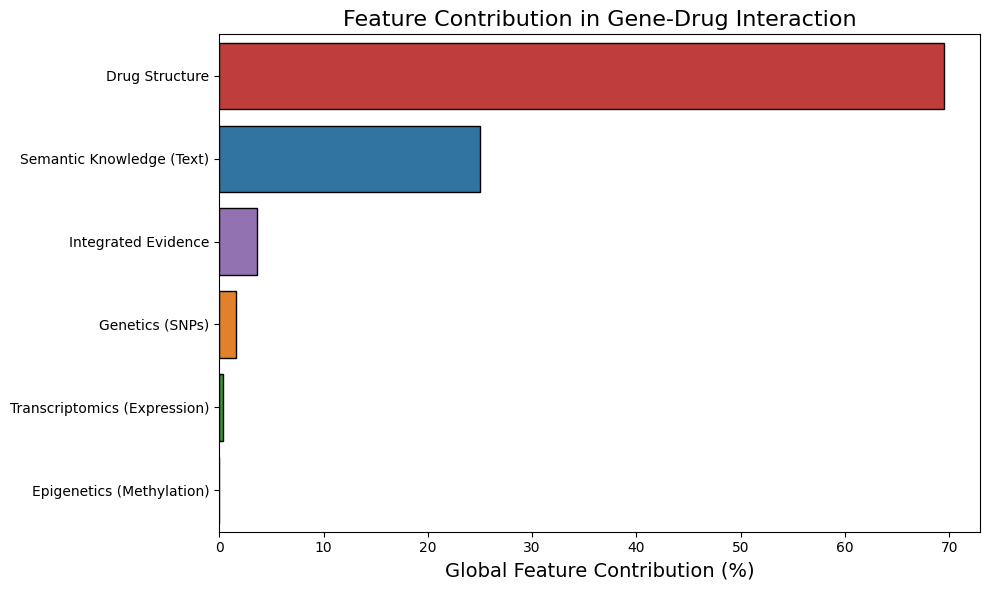

In [8]:
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MaxAbsScaler
import joblib
from rdkit import Chem
from dgllife.utils import CanonicalAtomFeaturizer

omics_feature_names = [
    'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10', 
    'ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore',
    'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05',
    'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10',
    'meth_mean_scz', 'meth_var_scz',
    
]

feature_categories = {
    'Genetics (SNPs)': [
        'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10',
        'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05'
    ],
    'Transcriptomics (Expression)': [
        'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10'
    ],
    'Epigenetics (Methylation)': ['meth_mean_scz', 'meth_var_scz'],
    'Integrated Evidence': ['ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore'],
}

DATA_FILE = '../../datasets/gene_drug_interaction/drugbank/test_data.csv'
MODEL_DIR = "./save/gene_drug_interaction/schizophrenia_interaction_model"
MODEL_PATH = f"{MODEL_DIR}/best_model.pth"
SCALER_PATH = f"{MODEL_DIR}/best_scaler.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, input_tensor):
        max_atoms = 100
        atom_dim = 74
        n_drug_feats = max_atoms * atom_dim
        
        atom_flat = input_tensor[:, :n_drug_feats]
        gene_feats = input_tensor[:, n_drug_feats:]
        
        atom_feats = atom_flat.view(-1, max_atoms, atom_dim)
        
        logits, _ = self.model(atom_feats, gene_feats)
        return logits

def load_data_and_model():
    df = pd.read_csv(DATA_FILE)

    gene_data = df.iloc[:, 2:-2].values.astype(float)
    scaler = joblib.load(SCALER_PATH)
    gene_data_scaled = scaler.transform(gene_data)
    
    atom_featurizer = CanonicalAtomFeaturizer()
    max_atoms = 100
    atom_dim = atom_featurizer.feat_size('h')
    
    atom_feats_list = []
    valid_indices = []
    
    print("Featurizing drugs for SHAP analysis...")
    for i, smiles in enumerate(df['smiles']):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None: continue
            feats = atom_featurizer(mol)['h']
            
            # Padding
            padded = torch.zeros(max_atoms, atom_dim)
            n = min(feats.shape[0], max_atoms)
            padded[:n, :] = feats[:n, :]
            
            atom_feats_list.append(padded)
            valid_indices.append(i)
        except:
            continue
            
    atom_tensor = torch.stack(atom_feats_list)
    gene_tensor = torch.tensor(gene_data_scaled[valid_indices], dtype=torch.float32)
    
    # (batch, max_atoms * atom_dim + gene_dim)
    combined_input = torch.cat([atom_tensor.view(atom_tensor.size(0), -1), gene_tensor], dim=1)
    
    gene_dim = gene_data.shape[1]
    model = DrugGeneInteractionTransformer(
        atom_dim=atom_dim, gene_dim=gene_dim, dim=128, depth=2, heads=4, dropout=0
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    return combined_input.to(device), model, atom_dim, max_atoms, gene_dim

def analyze_interaction_feature_importance():
    print("Loading data and model...")
    X_combined, model, atom_dim, max_atoms, gene_dim = load_data_and_model()
    
    np.random.seed(42)
    
    n_background = 10
    background_idx = np.random.choice(X_combined.shape[0], n_background, replace=False)
    background = X_combined[background_idx]
    
    n_test = 100
    test_idx = np.random.choice(X_combined.shape[0], n_test, replace=False)
    X_test = X_combined[test_idx]
    
    wrapper = ModelWrapper(model)
    explainer = shap.DeepExplainer(wrapper, background)
    
    print(f"Calculating SHAP values for {n_test} samples...")
    shap_values = explainer.shap_values(X_test,check_additivity=False)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
        

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    drug_end_idx = max_atoms * atom_dim
    omics_end_idx = drug_end_idx + 18
    
    category_importance = {}
    
    # 1. Drug Structure
    category_importance['Drug Structure'] = np.sum(mean_abs_shap[:drug_end_idx])
    
    # 2. Omics Features
    omics_shap = mean_abs_shap[drug_end_idx : omics_end_idx]
    for cat, feats in feature_categories.items():
        indices = [omics_feature_names.index(f) for f in feats]
        category_importance[cat] = np.sum(omics_shap[indices])
        
    # 3. Semantic Knowledge (Text)
    category_importance['Semantic Knowledge (Text)'] = np.sum(mean_abs_shap[omics_end_idx:])
    
    total_importance = sum(category_importance.values())
    category_pct = {k: (v / total_importance) * 100 for k, v in category_importance.items()}
    

    print("\n=== Interaction Feature Contribution Analysis ===")
    for k, v in category_pct.items():
        print(f"{k}: {v:.2f}%")
        
    plot_importance(category_pct)
    return category_pct

def plot_importance(category_pct):
    df_plot = pd.DataFrame(list(category_pct.items()), columns=['Category', 'Contribution'])
    df_plot = df_plot.sort_values('Contribution', ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = {
        'Drug Structure': '#d62728', 
        'Semantic Knowledge (Text)': '#1f77b4', 
        'Genetics (SNPs)': '#ff7f0e', 
        'Transcriptomics (Expression)': '#2ca02c', 
        'Epigenetics (Methylation)': '#8c564b', 
        'Integrated Evidence': '#9467bd'
    }
    palette = [colors.get(c, 'grey') for c in df_plot['Category']]
    
    sns.barplot(data=df_plot, x='Contribution', y='Category', palette=palette, edgecolor='black')
    
    plt.title('Feature Contribution in Gene-Drug Interaction', fontsize=16)
    plt.xlabel('Global Feature Contribution (%)', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('./save/gene_drug_interaction/scz_interaction_importance.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_interaction_feature_importance()

Model loaded successfully.
Saved attention map to Risperidone_attention.png


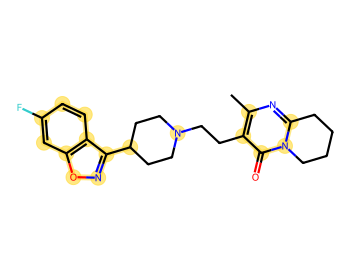

In [3]:
import io
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from rdkit import Chem
from rdkit.Chem.Draw import MolDraw2DCairo
from dgllife.utils import CanonicalAtomFeaturizer

def visualize_atom_attention_compact(
    smiles,
    model,
    atom_featurizer,
    device,
    save_path,
    top_k=5,
    img_size=(350, 280),
    highlight_color=(1.0, 0.85, 0.2, 0.6) 
):
    """
    Compact, publication-ready atom-level attention visualization
    """

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES: {smiles}")
        return

    atom_feats = atom_featurizer(mol)['h']
    atom_tensor = atom_feats.unsqueeze(0).to(device)

    # ---- extract attention ----
    model.eval()
    with torch.no_grad():
        attn = model.get_atom_attention(atom_tensor).squeeze()  # (n_atoms,)

    # normalize only for stability
    attn = attn - attn.min()
    if attn.max() > 0:
        attn = attn / attn.max()

    # select top-k atoms
    k = min(top_k, attn.shape[0])
    topk_idx = torch.topk(attn, k).indices.tolist()

    # ---- RDKit drawing ----
    drawer = MolDraw2DCairo(img_size[0], img_size[1])
    opts = drawer.drawOptions()
    opts.clearBackground = True
    opts.fillHighlights = True
    opts.bondLineWidth = 2.2

    highlight_atoms = {idx: 0.45 for idx in topk_idx}
    highlight_colors = {idx: highlight_color for idx in topk_idx}

    drawer.DrawMolecule(
        mol,
        highlightAtoms=topk_idx,
        highlightAtomColors=highlight_colors,
        highlightAtomRadii=highlight_atoms
    )
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))

    if save_path:
        img.save(save_path, dpi=(300, 300))
        print(f"Saved attention map to {save_path}")

    # display(img)
    return img
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ATOM_DIM = 74 
GENE_DIM = 18 + 768 
MODEL_PATH = "./save/gene_drug_interaction/schizophrenia_interaction_model/best_model.pth"

model = DrugGeneInteractionTransformer(
    atom_dim=ATOM_DIM, 
    gene_dim=GENE_DIM, 
    dim=128, 
    depth=2, 
    heads=4, 
    dropout=0
).to(device)

if os.path.exists(MODEL_PATH):

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("Model loaded successfully.")
else:
    print(f"Error: Model file not found at {MODEL_PATH}")

atom_featurizer = CanonicalAtomFeaturizer()


# Risperidone
target_drug_smiles = "CC1=C(CCN2CCC(CC2)C2=NOC3=C2C=CC(F)=C3)C(=O)N2CCCCC2=N1" 
visualize_atom_attention_compact(target_drug_smiles, model, atom_featurizer, device, save_path="Risperidone_attention.png",top_k=16)

# olanzapine
target_drug_smiles = "CN1CCN(CC1)C1=NC2=CC=CC=C2NC2=C1C=C(C)S2"
visualize_atom_attention_compact(target_drug_smiles, model, atom_featurizer, device, save_path="olanzapine_attention.png",top_k=13)


Saved attention map to olanzapine_attention.png


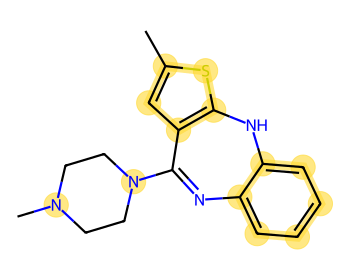

In [4]:
# olanzapine
target_drug_smiles = "CN1CCN(CC1)C1=NC2=CC=CC=C2NC2=C1C=C(C)S2"
visualize_atom_attention_compact(target_drug_smiles, model, atom_featurizer, device, save_path="olanzapine_attention.png",top_k=13)

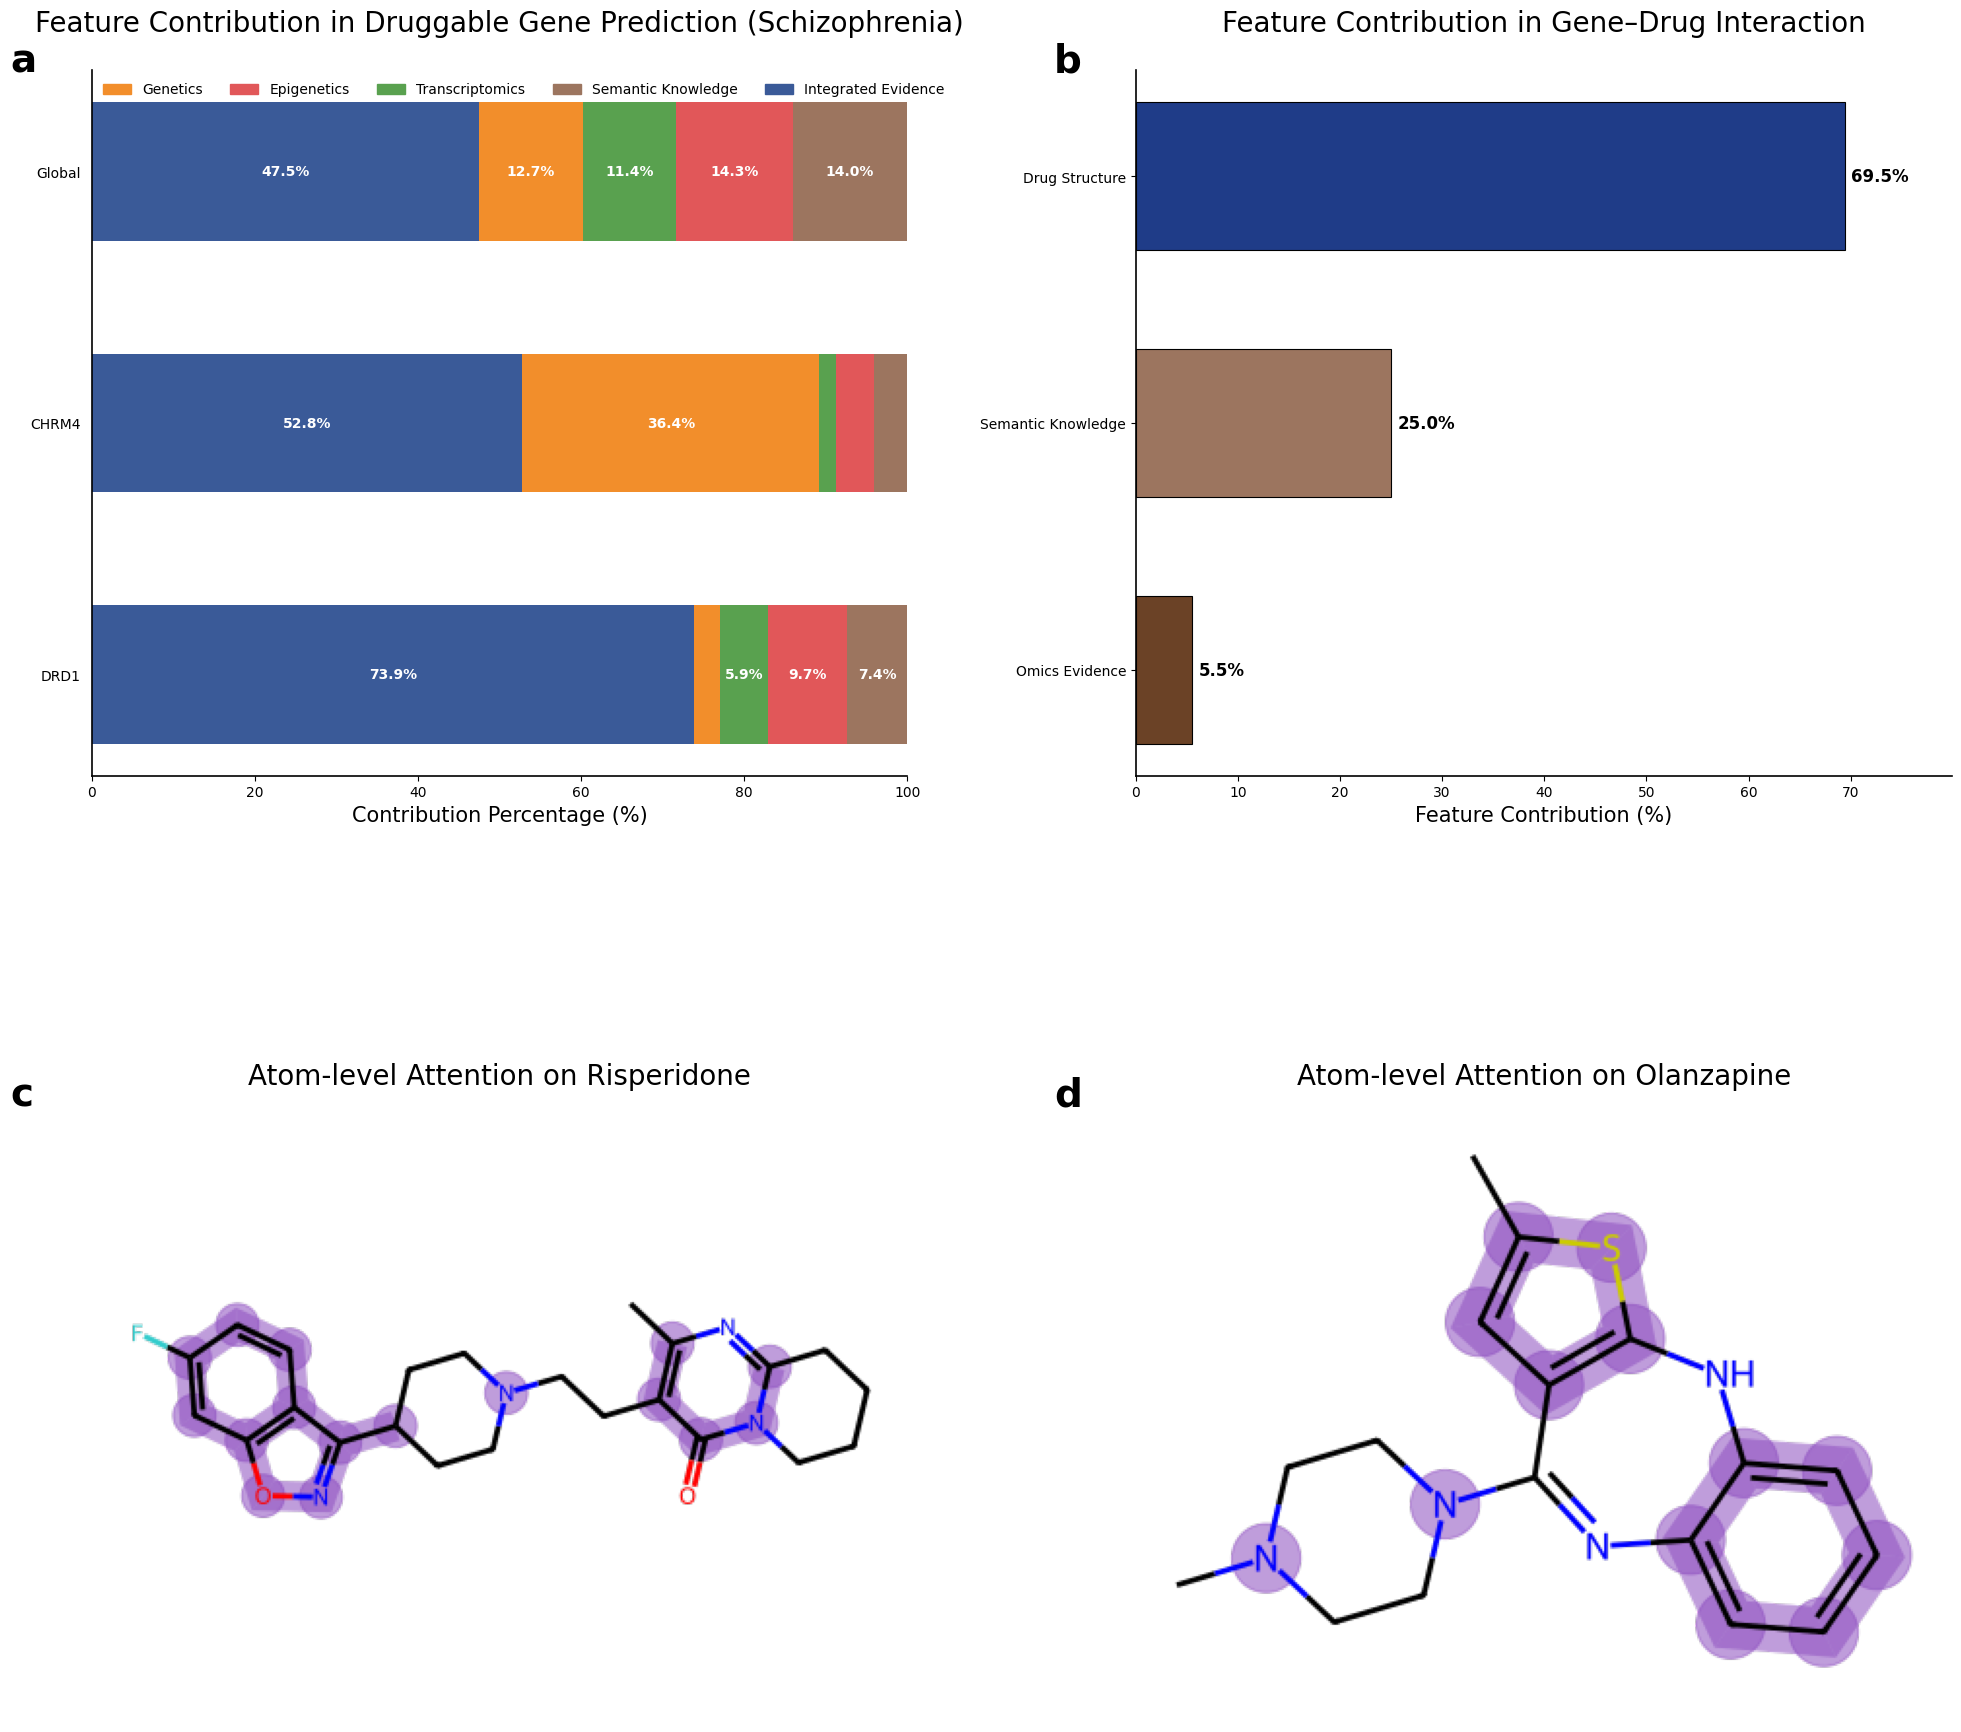

In [23]:
# =============================================================================
# Imports
# =============================================================================
import io
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib.patches as mpatches
from PIL import Image
from rdkit import Chem
from rdkit.Chem.Draw import MolDraw2DCairo
from dgllife.utils import CanonicalAtomFeaturizer

# =============================================================================
# Atom-level attention drawing (INLINE, no saving)
# =============================================================================
def draw_atom_attention_on_ax(
    ax,
    smiles,
    model,
    atom_featurizer,
    device,
    top_k=12,
    img_size=(420, 320),
    highlight_color=(0.55, 0.30, 0.75, 0.55)  
):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    atom_feats = atom_featurizer(mol)['h']
    atom_tensor = atom_feats.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        attn = model.get_atom_attention(atom_tensor).squeeze()

    # normalize
    attn = attn - attn.min()
    if attn.max() > 0:
        attn = attn / attn.max()

    k = min(top_k, attn.shape[0])
    topk_idx = torch.topk(attn, k).indices.tolist()

    drawer = MolDraw2DCairo(img_size[0], img_size[1])
    opts = drawer.drawOptions()
    opts.clearBackground = False
    opts.fillHighlights = True
    opts.bondLineWidth = 2.8
    opts.highlightBondWidthMultiplier = 14

    highlight_atoms = {i: 0.55 for i in topk_idx}
    highlight_colors = {i: highlight_color for i in topk_idx}

    drawer.DrawMolecule(
        mol,
        highlightAtoms=topk_idx,
        highlightAtomColors=highlight_colors,
        highlightAtomRadii=highlight_atoms
    )
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    ax.imshow(img)
    ax.axis('off')


# =============================================================================
# Bar chart utilities (fixed overlap & low-percentage handling)
# =============================================================================
def plot_compositional_bar_chart(ax, data, title, min_label_threshold=5.0):
    categories = data['categories']
    y_labels = list(categories.keys())
    y_pos = np.arange(len(y_labels))
    left_positions = np.zeros(len(y_labels))

    all_feature_labels = list(color_palette.keys())

    for feature_label in all_feature_labels:
        values = [
            categories[c]['values'][categories[c]['labels'].index(feature_label)]
            if feature_label in categories[c]['labels'] else 0
            for c in y_labels
        ]

        bars = ax.barh(
            y_pos, values, left=left_positions,
            height=0.55,
            color=color_palette.get(feature_label, 'grey')
        )

        for bar in bars:
            width = bar.get_width()
            if width >= min_label_threshold:
                ax.text(
                    bar.get_x() + width / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{width:.1f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white'
                )

        left_positions += np.array(values)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([textwrap.fill(l, 18) for l in y_labels])
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel('Contribution Percentage (%)', fontsize=15)
    ax.set_title(title, fontsize=20, pad=28)

    # spines
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='y', length=0, pad=8)


def plot_single_task_bar_chart(ax, data, title, min_label_threshold=5.0):
    labels = data['labels']
    values = data['values']
    y_pos = np.arange(len(labels))
    colors = [color_palette.get(l, 'grey') for l in labels]

    bars = ax.barh(
        y_pos, values,
        color=colors,
        edgecolor='black',
        linewidth=0.8,
        height=0.6
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, max(values) * 1.15)
    ax.set_xlabel("Feature Contribution (%)", fontsize=15)
    ax.set_title(title, fontsize=20, pad=28)

    for bar in bars:
        width = bar.get_width()
        if width >= min_label_threshold:
            ax.text(
                width + 0.6,
                bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                ha='left', va='center',
                fontsize=12, fontweight='bold'
            )

    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# =============================================================================
# Data
# =============================================================================
composition_data_a = {
    'title': 'Feature Contribution in Druggable Gene Prediction (Schizophrenia)',
    'categories': {
        'Global': {
            'labels': ['Integrated Evidence','Epigenetics','Genetics','Transcriptomics','Semantic Knowledge'],
            'values': [47.52, 14.28, 12.71, 11.43, 14.05]
        },
        'CHRM4': {
            'labels': ['Integrated Evidence','Genetics','Epigenetics','Semantic Knowledge','Transcriptomics'],
            'values': [52.81, 36.38, 4.71, 4.08, 2.02]
        },
        'DRD1': {
            'labels': ['Integrated Evidence','Epigenetics','Semantic Knowledge','Transcriptomics','Genetics'],
            'values': [73.88, 9.67, 7.37, 5.90, 3.18]
        }
    }
}

composition_data_b = {
    'labels': ['Drug Structure', 'Semantic Knowledge', 'Omics Evidence'],
    'values': [69.46, 25.00, 5.54]
}

color_palette = {
    'Integrated Evidence': '#3a5a98',
    'Genetics': '#f28e2b',
    'Transcriptomics': '#59a14f',
    'Epigenetics': '#e15759',
    'Semantic Knowledge': '#9c755f',
    'Drug Structure': '#1f3c88',
    'Omics Evidence': '#6b4226'
}

# =============================================================================
# Model loading
# =============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ATOM_DIM = 74
GENE_DIM = 18 + 768
MODEL_PATH = "./save/gene_drug_interaction/schizophrenia_interaction_model/best_model.pth"

model = DrugGeneInteractionTransformer(
    atom_dim=ATOM_DIM,
    gene_dim=GENE_DIM,
    dim=128,
    depth=2,
    heads=4,
    dropout=0
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
atom_featurizer = CanonicalAtomFeaturizer()

# =============================================================================
# Figure layout
# =============================================================================
fig = plt.figure(figsize=(24, 22))
gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.28)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# a / b
plot_compositional_bar_chart(ax_a, composition_data_a, composition_data_a['title'])
plot_single_task_bar_chart(ax_b, composition_data_b, 'Feature Contribution in Gene–Drug Interaction')

# legend for a
used_labels = set()
for cat in composition_data_a['categories'].values():
    used_labels.update(cat['labels'])

ax_a.legend(
    handles=[mpatches.Patch(color=color_palette[l], label=l) for l in used_labels],
    loc='upper center',
    bbox_to_anchor=(0.53, 1),
    ncol=5,
    frameon=False,
    fontsize=10
)

# c / d (INLINE drawing)
draw_atom_attention_on_ax(
    ax_c,
    "CC1=C(CCN2CCC(CC2)C2=NOC3=C2C=CC(F)=C3)C(=O)N2CCCCC2=N1",
    model, atom_featurizer, device, top_k=16
)
ax_c.set_title("Atom-level Attention on Risperidone", fontsize=20, pad=12)

draw_atom_attention_on_ax(
    ax_d,
    "CN1CCN(CC1)C1=NC2=CC=CC=C2NC2=C1C=C(C)S2",
    model, atom_featurizer, device, top_k=13
)
ax_d.set_title("Atom-level Attention on Olanzapine", fontsize=20, pad=12)

# panel labels
for label, ax in zip(['a', 'b', 'c', 'd'], [ax_a, ax_b, ax_c, ax_d]):
    ax.text(-0.10, 1.04, label, transform=ax.transAxes,
            fontsize=28, fontweight='bold', va='top')

plt.savefig("./results/Fig4_SCZ.png", dpi=300, bbox_inches="tight")
plt.show()


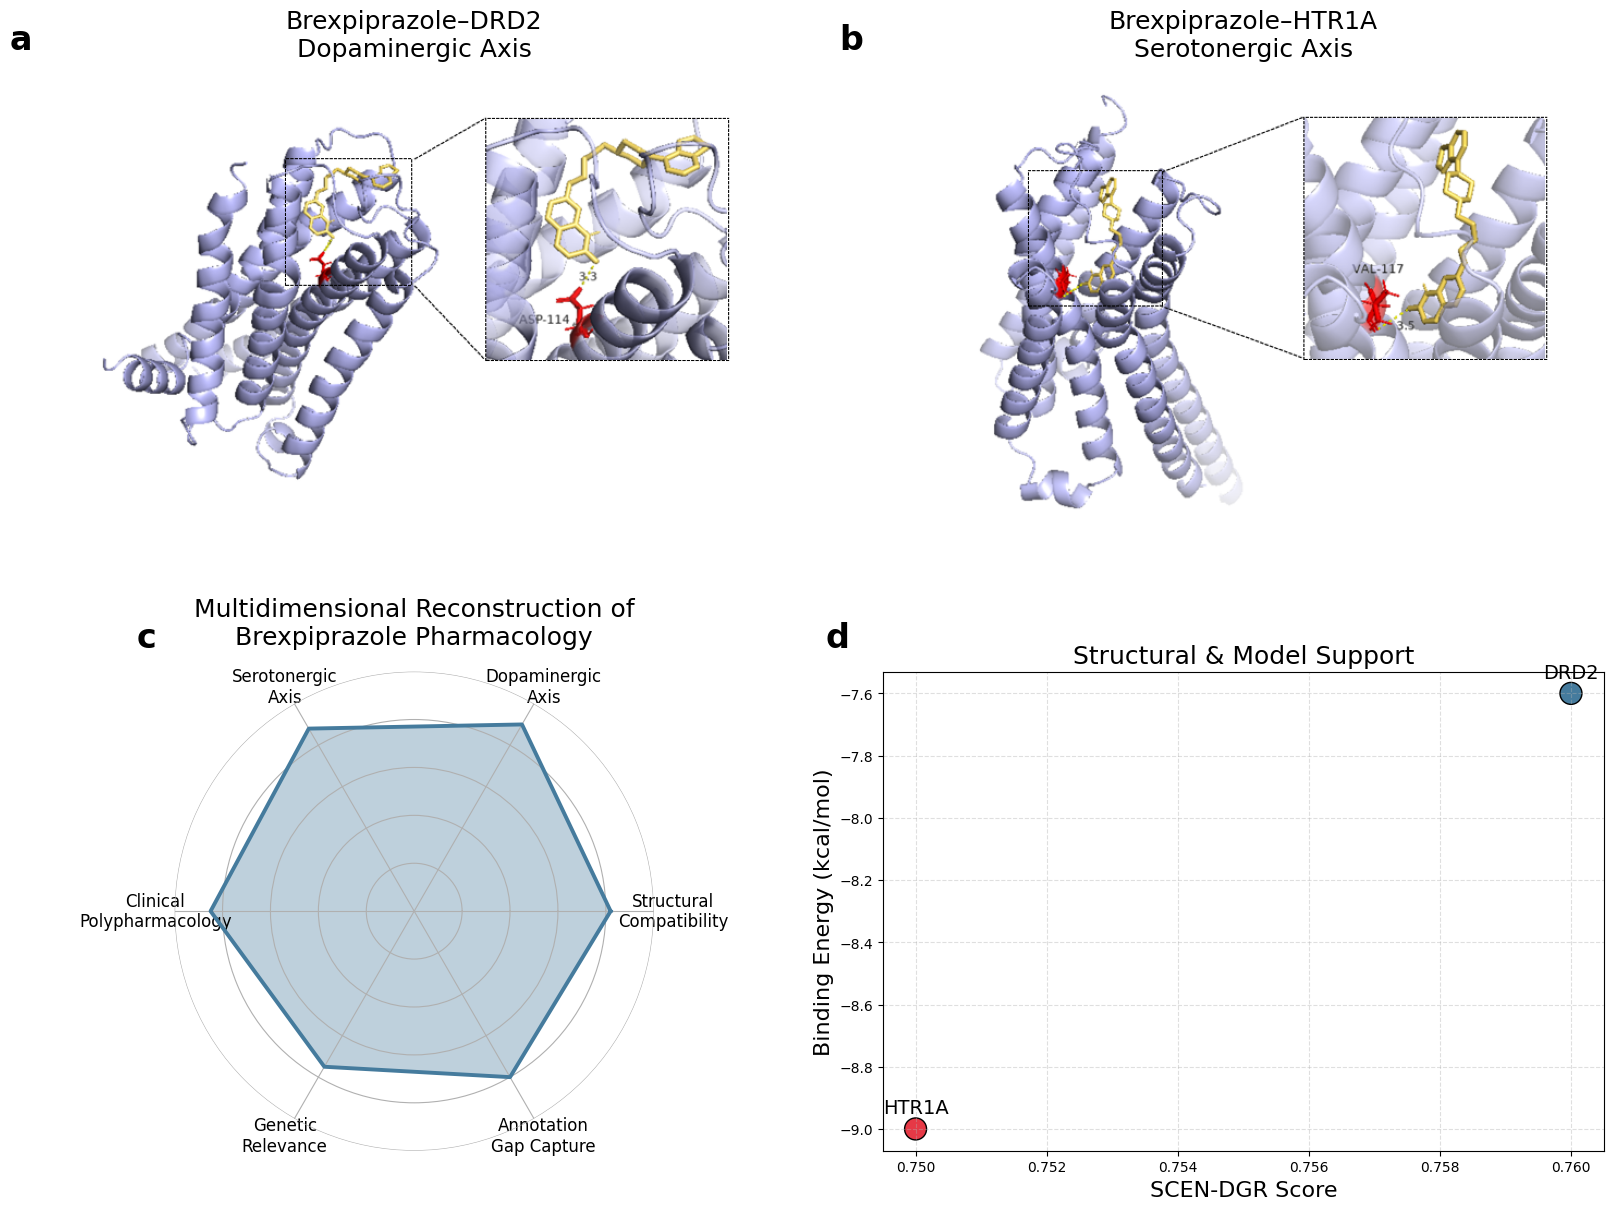

In [7]:
# Fig.7 Brexpiprazole pharmacological axis
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import FancyBboxPatch

def load_img(path):
    return Image.open(path)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.15)

# a) DRD2 docking
ax_a = fig.add_subplot(gs[0, 0])
ax_a.imshow(load_img("Brexpiprazole_DRD2.png"))
ax_a.axis("off")
ax_a.set_title("Brexpiprazole–DRD2\nDopaminergic Axis",
               fontsize=18, pad=12)

# b) HTR1A docking
ax_b = fig.add_subplot(gs[0, 1])
ax_b.imshow(load_img("Brexpiprazole_HTR1A.png"))
ax_b.axis("off")
ax_b.set_title("Brexpiprazole–HTR1A\nSerotonergic Axis",
               fontsize=18, pad=12)

# === Fig.7c Radar: Clinical Pharmacological Axis ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes, register_projection

def radar_factory(num_vars):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):
        name = 'radar'
        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                line.set_data(np.append(x, x[0]), np.append(y, y[0]))

    register_projection(RadarAxes)
    return theta

metrics = [
    "Structural\nCompatibility",
    "Dopaminergic\nAxis",
    "Serotonergic\nAxis",
    "Clinical\nPolypharmacology",
    "Genetic\nRelevance",
    "Annotation\nGap Capture"
]

theta = radar_factory(len(metrics))

brexpiprazole_profile = [0.82, 0.90, 0.88, 0.85, 0.75, 0.80]

ax_c = fig.add_subplot(gs[1, 0], projection='radar')
ax_c.plot(theta, brexpiprazole_profile, color="#457b9d", linewidth=2.8)
ax_c.fill(theta, brexpiprazole_profile, color="#457b9d", alpha=0.35)

ax_c.set_xticks(theta)
ax_c.set_xticklabels(metrics, fontsize=12)
ax_c.set_yticklabels([])
ax_c.set_ylim(0, 1.0)
ax_c.set_title(
    "Multidimensional Reconstruction of\nBrexpiprazole Pharmacology",
    fontsize=18, pad=20
)
ax_c.spines['polar'].set_visible(False)

# d) Quantitative mini-scatter
ax_d = fig.add_subplot(gs[1, 1])
ax_d.scatter([0.76, 0.75], [-7.6, -9.0],
             s=250, c=["#457b9d", "#e63946"],
             edgecolor="black")
ax_d.text(0.76, -7.55, "DRD2", ha="center", fontsize=14)
ax_d.text(0.75, -8.95, "HTR1A", ha="center", fontsize=14)

ax_d.set_xlabel("SCEN-DGR Score", fontsize=16)
ax_d.set_ylabel("Binding Energy (kcal/mol)", fontsize=16)
ax_d.set_title("Structural & Model Support", fontsize=18)
ax_d.grid(True, linestyle="--", alpha=0.4)

# panel labels
for label, ax in zip("abcd", [ax_a, ax_b, ax_c, ax_d]):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes,
            fontsize=24, fontweight="bold")

plt.savefig("Fig7_Brexpiprazole_axis.png", dpi=300, bbox_inches="tight")
plt.show()


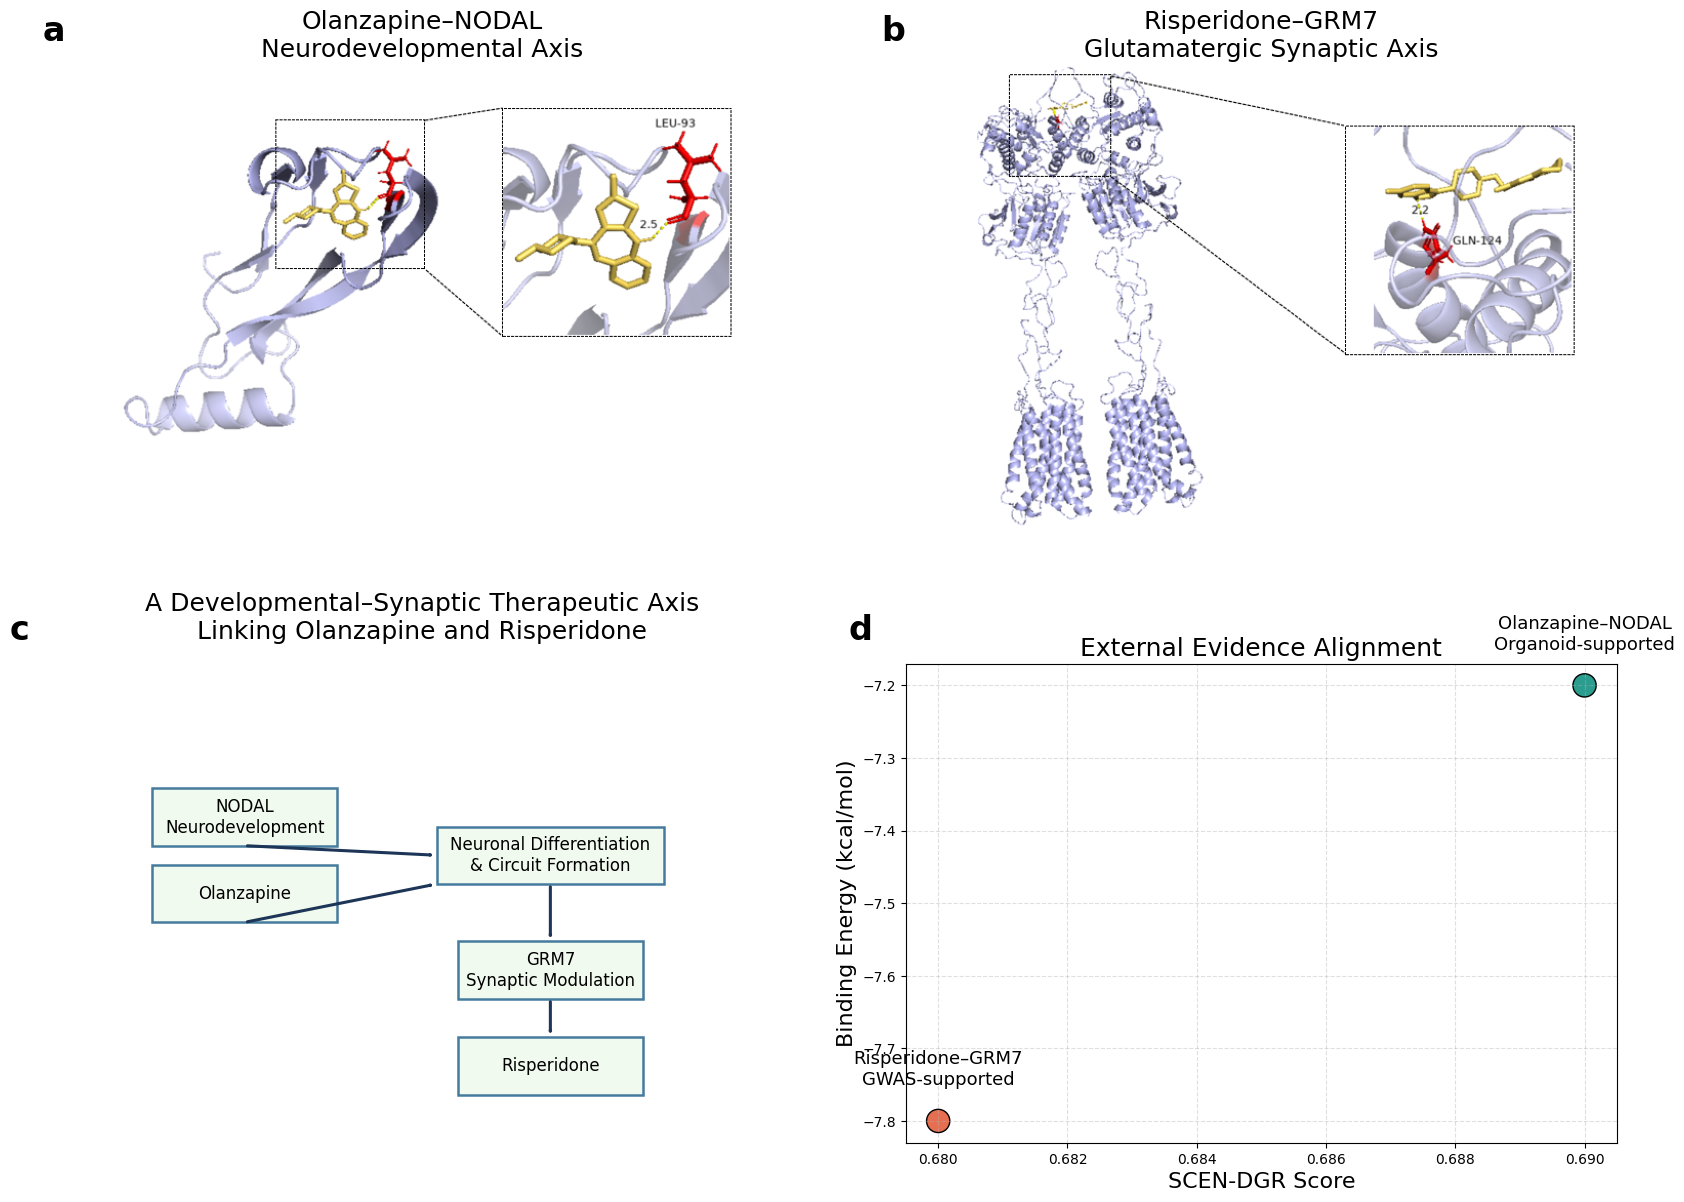

In [18]:
# Fig.8 Developmental–Synaptic Axis
import matplotlib.pyplot as plt
from PIL import Image

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.18)

# a) Olanzapine–NODAL
ax_a = fig.add_subplot(gs[0, 0])
ax_a.imshow(Image.open("Olanzapine_NODAL.png"))
ax_a.axis("off")
ax_a.set_title("Olanzapine–NODAL\nNeurodevelopmental Axis",
               fontsize=18)

# b) Risperidone–GRM7
ax_b = fig.add_subplot(gs[0, 1])
ax_b.imshow(Image.open("Risperidone_GRM7.png"))
ax_b.axis("off")
ax_b.set_title("Risperidone–GRM7\nGlutamatergic Synaptic Axis",
               fontsize=18)

# === Fig.8c Revised: Developmental–Synaptic Therapeutic Axis ===
from matplotlib.patches import Rectangle, FancyArrowPatch

ax_c = fig.add_subplot(gs[1, 0])
ax_c.axis("off")

# ---------- Box definitions ----------
boxes = {
    "NODAL":        (0.12, 0.62, "NODAL\nNeurodevelopment"),
    "Olanzapine":   (0.12, 0.46, "Olanzapine"),
    "Hub":          (0.52, 0.54, "Neuronal Differentiation\n& Circuit Formation"),
    "GRM7":         (0.55, 0.30, "GRM7\nSynaptic Modulation"),
    "Risperidone":  (0.55, 0.10, "Risperidone")
}

# ---------- Draw boxes ----------
for key, (x, y, label) in boxes.items():
    width = 0.32 if key == "Hub" else 0.26   # Hub wider to avoid text overflow
    ax_c.add_patch(
        Rectangle(
            (x, y), width, 0.12,
            facecolor="#f1faee",
            edgecolor="#457b9d",
            linewidth=1.8
        )
    )
    ax_c.text(
        x + width / 2, y + 0.06,
        label,
        ha="center", va="center",
        fontsize=12, wrap=True
    )

# ---------- Draw arrows ----------
arrows = [
    # NODAL -> Hub
    ((0.25, 0.62), (0.52, 0.60)),
    # Olanzapine -> Hub  (FIXED: now fully connected)
    ((0.25, 0.46), (0.52, 0.54)),
    # Hub -> GRM7
    ((0.68, 0.54), (0.68, 0.42)),
    # GRM7 -> Risperidone
    ((0.68, 0.30), (0.68, 0.22))
]

for start, end in arrows:
    ax_c.add_patch(
        FancyArrowPatch(
            start, end,
            arrowstyle="->",
            linewidth=2.2,
            color="#1d3557"
        )
    )

# ---------- Title ----------
ax_c.set_title(
    "A Developmental–Synaptic Therapeutic Axis\nLinking Olanzapine and Risperidone",
    fontsize=18,
    pad=18
)

# d) Evidence alignment
ax_d = fig.add_subplot(gs[1, 1])
ax_d.scatter([0.69, 0.68], [-7.2, -7.8],
             s=280, c=["#2a9d8f", "#e76f51"],
             edgecolor="black")
ax_d.text(0.69, -7.15, "Olanzapine–NODAL\nOrganoid-supported",
          ha="center", fontsize=13)
ax_d.text(0.68, -7.75, "Risperidone–GRM7\nGWAS-supported",
          ha="center", fontsize=13)

ax_d.set_xlabel("SCEN-DGR Score", fontsize=16)
ax_d.set_ylabel("Binding Energy (kcal/mol)", fontsize=16)
ax_d.set_title("External Evidence Alignment", fontsize=18)
ax_d.grid(True, linestyle="--", alpha=0.4)

for label, ax in zip("abcd", [ax_a, ax_b, ax_c, ax_d]):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes,
            fontsize=24, fontweight="bold")

plt.savefig("./save/gene_drug_interaction/Fig8_Developmental_Synaptic_Axis.png", dpi=300, bbox_inches="tight")
plt.show()
